# Phase 1.5 v7 — 외부지표 Ablation Study (`07_ablation_study.ipynb`)

> **목적**: v6 (8ch) 가 모든 종목에서 악화한 원인 진단.
> 각 외부지표 1개씩 제거 후 학습 → 어느 지표가 도움이고 어느 지표가 noise 인지 명확화.

## v6 (8ch) 의 충격적 결과 회상

| 종목 | v4 RMSE | **v6 RMSE** | Δ |
|---|---|---|---|
| SPY | 0.32 | **0.65** | +103% ❌ |
| QQQ | 0.29 | **0.69** | +136% ❌ |
| 평균 | 0.30 | 0.67 | +123% ❌ |

→ **모든 종목 악화** — 어느 외부지표가 진짜 문제인지 식별 필요

## Ablation Study 설계

기존 v6 (8ch): rv_d, rv_w, rv_m, vix, **vvix, skew, tnx, dxy**

각 외부지표 1개씩 제거 (총 4 조합):

| Ablation | 입력 채널 | input_size | 의미 |
|---|---|---|---|
| **v6 - VVIX** | 4ch + skew + tnx + dxy | 7 | VVIX 효과 측정 |
| **v6 - SKEW** | 4ch + vvix + tnx + dxy | 7 | SKEW 효과 측정 |
| **v6 - TNX** | 4ch + vvix + skew + dxy | 7 | ^TNX 효과 측정 |
| **v6 - DXY** | 4ch + vvix + skew + tnx | 7 | DXY 효과 측정 |

## 해석 방법

```
Δ_RMSE = (v7 ablation) - (v6 full 8ch)

Δ > 0 (양수):  해당 feature 가 도움 → 제거 시 악화
Δ < 0 (음수):  해당 feature 가 noise → 제거 시 개선 ⭐
Δ ≈ 0:         영향 미미
```

**가장 큰 음수 Δ**: 가장 큰 noise 후보 (제거 시 개선 폭 큼)

## 종목 + 시간

- **SPY, QQQ 만** (2 종목, 빠른 검증)
- 4 조합 × 2 종목 × 50초 = **~8분 GPU**

## 본 노트북 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + GPU + 기존 v4/v6 결과 로드 |
| §2 | 외부지표 데이터 + 8 채널 사전 준비 |
| §3 | Ablation 학습 함수 (input_size = 7) |
| §4 | 4 조합 학습 (SPY, QQQ) |
| §5 | 종합 결과 표 (v4 / v6 / ablation 4) |
| §6 | 시각화 (외부지표 importance bar) |
| §7 | 결론 + 보고서 자동 생성 |


## §1. 환경 + GPU + 기존 v4/v6 결과 로드


In [1]:
import sys
import json
import time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 device: {device}')

# 기존 v4 (multi_asset) 와 v6 결과 로드
TICKERS = ['SPY', 'QQQ']

V4_DIR = RESULTS_DIR / 'multi_asset'
V6_DIR = RESULTS_DIR / 'lstm_v6_9ch'

prior_results = {'v4': {}, 'v6': {}}
for tk in TICKERS:
    # v4 best (multi_asset 의 결과)
    with open(V4_DIR / f'{tk}_v4_metrics.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
        prior_results['v4'][tk] = data['summary']['lstm_v4']
    # v6 full 8ch
    with open(V6_DIR / f'{tk}_metrics.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
        prior_results['v6'][tk] = data['summary']
    print(f'  [{tk}] v4 RMSE={prior_results["v4"][tk]["rmse"]["mean"]:.4f}, '
          f'v6 RMSE={prior_results["v6"][tk]["rmse"]["mean"]:.4f}')


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
사용 device: cuda
  [SPY] v4 RMSE=0.3208, v6 RMSE=0.6503
  [QQQ] v4 RMSE=0.2921, v6 RMSE=0.6880


## §2. 외부지표 데이터 + 8채널 사전 준비


In [2]:
import pandas as pd
import numpy as np
from scripts.targets_volatility import build_daily_target_logrv_21d

ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
WINDOW = 21
SEQ_LEN = 63
HAR_W_WINDOW = 5
HAR_M_WINDOW = 22


def load_indicator(name: str) -> pd.Series:
    csv_path = RAW_DATA_DIR / f'{name}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    col = 'Close' if 'Close' in df.columns else df.columns[0]
    return df[[col]].rename(columns={col: name})


# 외부지표 모두 로드 (캐시 활용)
indicator_series = {
    'VIX':  load_indicator('VIX'),
    'VVIX': load_indicator('VVIX'),
    'SKEW': load_indicator('SKEW'),
    'TNX':  load_indicator('TNX'),
    'DXY':  load_indicator('DXY'),
}


def load_ticker_full(ticker: str) -> pd.DataFrame:
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    return df


def prepare_ticker_df(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.loc[ANALYSIS_START:ANALYSIS_END].copy()
    for name, ind in indicator_series.items():
        df = df.join(ind, how='left')
        df[name] = df[name].ffill()
    df['rv_d'] = df['log_ret'].abs()
    df['rv_w'] = (df['log_ret'] ** 2).rolling(HAR_W_WINDOW).mean().pow(0.5)
    df['rv_m'] = (df['log_ret'] ** 2).rolling(HAR_M_WINDOW).mean().pow(0.5)
    df['vix_log']  = np.log(df['VIX'])
    df['vvix_log'] = np.log(df['VVIX'])
    df['skew_log'] = np.log(df['SKEW'])
    df['tnx_log']  = np.log(df['TNX'].clip(lower=0.01))
    df['dxy_log']  = np.log(df['DXY'])
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    return df


# SPY, QQQ 데이터 준비
analysis_dict = {}
for tk in TICKERS:
    raw = load_ticker_full(tk)
    df = prepare_ticker_df(raw)
    analysis_dict[tk] = df
    print(f'{tk}: n={len(df)}, 유효 target={int(df["target_logrv"].notna().sum())}')

N_VALID = min(int(analysis_dict[tk]['target_logrv'].notna().sum()) for tk in TICKERS)


SPY: n=2514, 유효 target=2493
QQQ: n=2514, 유효 target=2493


## §3. Ablation 학습 함수 — 7채널 입력

각 ablation 마다 **다른 외부지표 1개 제거** → input_size=7 로 학습.
hyperparameter 는 v4 best 동일 (hidden=32, dropout=0.3, lr=1e-3, IS=1250, emb=63).


In [3]:
from torch.utils.data import TensorDataset, DataLoader
from scripts.dataset import build_fold_datasets, walk_forward_folds
from scripts.models import LSTMRegressor
from scripts.train import train_one_fold

# Hyperparameter (v4 best 동일)
HIDDEN = 32
NUM_LAYERS = 1
DROPOUT = 0.3
LR = 1e-3
WEIGHT_DECAY = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 3
LOSS_TYPE = 'mse'
BATCH_SIZE = 32
VAL_RATIO = 0.2
SEED = 42

IS_LEN = 1250
PURGE = 21
EMBARGO = 63
OOS_LEN = 21
STEP = 21


# 4 ablation 조합 정의
ABLATIONS = {
    '-VVIX': ['rv_w', 'rv_m', 'vix_log', 'skew_log', 'tnx_log', 'dxy_log'],   # VVIX 제거
    '-SKEW': ['rv_w', 'rv_m', 'vix_log', 'vvix_log', 'tnx_log', 'dxy_log'],   # SKEW 제거
    '-TNX':  ['rv_w', 'rv_m', 'vix_log', 'vvix_log', 'skew_log', 'dxy_log'],   # TNX 제거
    '-DXY':  ['rv_w', 'rv_m', 'vix_log', 'vvix_log', 'skew_log', 'tnx_log'],   # DXY 제거
}
INPUT_SIZE = 7   # 모든 ablation 동일


def build_input_ablation(df: pd.DataFrame, extra_cols: list):
    """series=rv_d, extra=지정된 6 컬럼."""
    series = df['rv_d'].fillna(0.0).values
    extra_arrays = []
    for col in extra_cols:
        extra_arrays.append(df[col].fillna(method='ffill').fillna(0.0).values)
    extra = np.column_stack(extra_arrays)
    return series, extra


def build_train_val_loaders(train_ds, val_ratio=VAL_RATIO, batch_size=BATCH_SIZE):
    n = len(train_ds)
    n_val = max(1, int(n * val_ratio))
    n_tr = n - n_val
    train_sub = TensorDataset(train_ds.X[:n_tr], train_ds.y[:n_tr])
    val_sub   = TensorDataset(train_ds.X[n_tr:], train_ds.y[n_tr:])
    tr_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(val_sub, batch_size=max(1, n_val), shuffle=False)
    return tr_loader, va_loader


def train_ablation(ticker: str, df: pd.DataFrame, extra_cols: list, folds: list):
    series, extra = build_input_ablation(df, extra_cols)
    target = df['target_logrv'].values

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if device.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)

    fold_out = []
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        tr_ds_k, te_ds_k, _ = build_fold_datasets(
            series=series, train_idx=tr_idx, test_idx=te_idx,
            seq_len=SEQ_LEN, extra_features=extra, target_series=target,
        )
        tr_loader, va_loader = build_train_val_loaders(tr_ds_k)
        model_k = LSTMRegressor(
            input_size=INPUT_SIZE, hidden_size=HIDDEN,
            num_layers=NUM_LAYERS, dropout=DROPOUT, batch_first=True,
        )
        result = train_one_fold(
            model_k, tr_loader, va_loader,
            max_epochs=MAX_EPOCHS, early_stop_patience=PATIENCE,
            lr=LR, weight_decay=WEIGHT_DECAY, lr_patience=LR_PATIENCE,
            loss_type=LOSS_TYPE, device=device, verbose=False,
        )
        model_k.load_state_dict(result['best_state_dict'])
        model_k.to(device).eval()
        with torch.no_grad():
            y_pred = model_k(te_ds_k.X.to(device)).cpu().numpy().flatten()
        y_true = te_ds_k.y.numpy()
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        fold_out.append({
            'fold': k,
            'y_true_test': y_true.astype(float).tolist(),
            'y_pred_test': y_pred.astype(float).tolist(),
            'best_epoch': int(result['best_epoch']),
        })
    elapsed = time.time() - t_start
    return fold_out, elapsed


print('학습 함수 정의 완료')


학습 함수 정의 완료


## §4. 4 조합 × 2 종목 학습 (~8분 GPU)


In [4]:
# Walk-Forward folds
folds = walk_forward_folds(
    n=N_VALID, is_len=IS_LEN, purge=PURGE, emb=EMBARGO,
    oos_len=OOS_LEN, step=STEP,
)
N_FOLDS = len(folds)
print(f'fold 수: {N_FOLDS}')


# 학습 실행
print()
print('=' * 80)
print('Ablation Study — 4 조합 × 2 종목 학습')
print('=' * 80)

ablation_results = {}   # {(ticker, ablation): fold_out}
t_total_start = time.time()
for tk in TICKERS:
    print(f'\n[{tk}]')
    df = analysis_dict[tk]
    for ab_name, ab_cols in ABLATIONS.items():
        fold_out, elapsed = train_ablation(tk, df, ab_cols, folds)
        ablation_results[(tk, ab_name)] = fold_out
        print(f'  {ab_name:<10} input={len(ab_cols)+1}ch  완료 ({elapsed:.0f}s)')

t_total_elapsed = time.time() - t_total_start
print(f'\n전체 완료 — 총 {t_total_elapsed/60:.1f}분')


fold 수: 55

Ablation Study — 4 조합 × 2 종목 학습

[SPY]


C:\Users\gorhk\AppData\Local\Temp\ipykernel_56776\3941827901.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  extra_arrays.append(df[col].fillna(method='ffill').fillna(0.0).values)


  -VVIX      input=7ch  완료 (71s)


C:\Users\gorhk\AppData\Local\Temp\ipykernel_56776\3941827901.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  extra_arrays.append(df[col].fillna(method='ffill').fillna(0.0).values)


  -SKEW      input=7ch  완료 (73s)


...

  -SKEW      input=7ch  완료 (71s)


C:\Users\gorhk\AppData\Local\Temp\ipykernel_56776\3941827901.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  extra_arrays.append(df[col].fillna(method='ffill').fillna(0.0).values)


  -TNX       input=7ch  완료 (59s)


C:\Users\gorhk\AppData\Local\Temp\ipykernel_56776\3941827901.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  extra_arrays.append(df[col].fillna(method='ffill').fillna(0.0).values)


  -DXY       input=7ch  완료 (68s)

전체 완료 — 총 9.0분


## §5. 종합 결과 표 — v4 / v6 / Ablation 4 비교


In [5]:
from scripts.metrics_volatility import (
    rmse, mae, qlike, r2_train_mean, pred_std_ratio, summarize_folds_volatility,
)


def compute_metrics(folds_out, target_series):
    per_fold = []
    for k, fp in enumerate(folds_out):
        y_true = np.array(fp['y_true_test'])
        y_pred = np.array(fp['y_pred_test'])
        tr_idx = folds[k][0]
        y_train = target_series.values[tr_idx]
        y_train = y_train[np.isfinite(y_train)]
        per_fold.append({
            'rmse': rmse(y_true, y_pred),
            'qlike': qlike(y_true, y_pred),
            'r2_train_mean': r2_train_mean(y_true, y_pred, y_train),
            'pred_std_ratio': pred_std_ratio(y_true, y_pred),
        })
    return per_fold


# Ablation 메트릭 계산
ablation_summary = {}
for tk in TICKERS:
    df = analysis_dict[tk]
    target = df['target_logrv']
    ablation_summary[tk] = {}
    for ab_name in ABLATIONS:
        per_fold = compute_metrics(ablation_results[(tk, ab_name)], target)
        ablation_summary[tk][ab_name] = summarize_folds_volatility(per_fold)


# 종합 비교 표
print('=' * 110)
print('Ablation Study — RMSE 비교 (v4 / v6 full / -VVIX / -SKEW / -TNX / -DXY)')
print('=' * 110)
print(f'  {"ticker":<8} {"v4 (4ch)":>12} {"v6 full (8ch)":>14} '
      f'{"-VVIX":>10} {"-SKEW":>10} {"-TNX":>10} {"-DXY":>10}')
print('  ' + '-' * 100)
for tk in TICKERS:
    v4_r = prior_results['v4'][tk]['rmse']['mean']
    v6_r = prior_results['v6'][tk]['rmse']['mean']
    print(f'  {tk:<8} {v4_r:>12.4f} {v6_r:>14.4f}', end='')
    for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']:
        ab_r = ablation_summary[tk][ab]['rmse']['mean']
        print(f' {ab_r:>10.4f}', end='')
    print()

print()
print('=' * 110)
print('Ablation 효과 — 각 외부지표 제거 시 v6 (full 8ch) 대비 RMSE 변화')
print('  Δ > 0 양수: 그 feature 가 도움 (제거 시 악화)')
print('  Δ < 0 음수: 그 feature 가 noise (제거 시 개선) ⭐')
print('=' * 110)
print(f'  {"ticker":<8} {"-VVIX Δ":>12} {"-SKEW Δ":>12} {"-TNX Δ":>12} {"-DXY Δ":>12}')
print('  ' + '-' * 75)
for tk in TICKERS:
    v6_r = prior_results['v6'][tk]['rmse']['mean']
    print(f'  {tk:<8}', end='')
    for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']:
        ab_r = ablation_summary[tk][ab]['rmse']['mean']
        delta = ab_r - v6_r   # Δ > 0 = 악화 (그 feature 도움)
                              # Δ < 0 = 개선 (그 feature noise)
        marker = ' ⭐' if delta < 0 else '  '
        print(f' {delta:>+10.4f}{marker}', end='')
    print()

# 평균 (SPY+QQQ)
print(f'\n  {"avg":<8}', end='')
for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']:
    avg_delta = np.mean([
        ablation_summary[tk][ab]['rmse']['mean'] - prior_results['v6'][tk]['rmse']['mean']
        for tk in TICKERS
    ])
    marker = ' ⭐' if avg_delta < 0 else '  '
    print(f' {avg_delta:>+10.4f}{marker}', end='')
print()


Ablation Study — RMSE 비교 (v4 / v6 full / -VVIX / -SKEW / -TNX / -DXY)
  ticker       v4 (4ch)  v6 full (8ch)      -VVIX      -SKEW       -TNX       -DXY
  ----------------------------------------------------------------------------------------------------
  SPY            0.3208         0.6503     0.5382     0.4101     0.3593     0.4304
  QQQ            0.2921         0.6880     0.3718     0.3854     0.3624     0.4142

Ablation 효과 — 각 외부지표 제거 시 v6 (full 8ch) 대비 RMSE 변화
  Δ > 0 양수: 그 feature 가 도움 (제거 시 악화)
  Δ < 0 음수: 그 feature 가 noise (제거 시 개선) ⭐
  ticker        -VVIX Δ      -SKEW Δ       -TNX Δ       -DXY Δ
  ---------------------------------------------------------------------------
  SPY         -0.1121 ⭐    -0.2402 ⭐    -0.2910 ⭐    -0.2199 ⭐
  QQQ         -0.3162 ⭐    -0.3026 ⭐    -0.3256 ⭐    -0.2738 ⭐

  avg         -0.2141 ⭐    -0.2714 ⭐    -0.3083 ⭐    -0.2468 ⭐


## §6. 시각화 — 외부지표 Importance


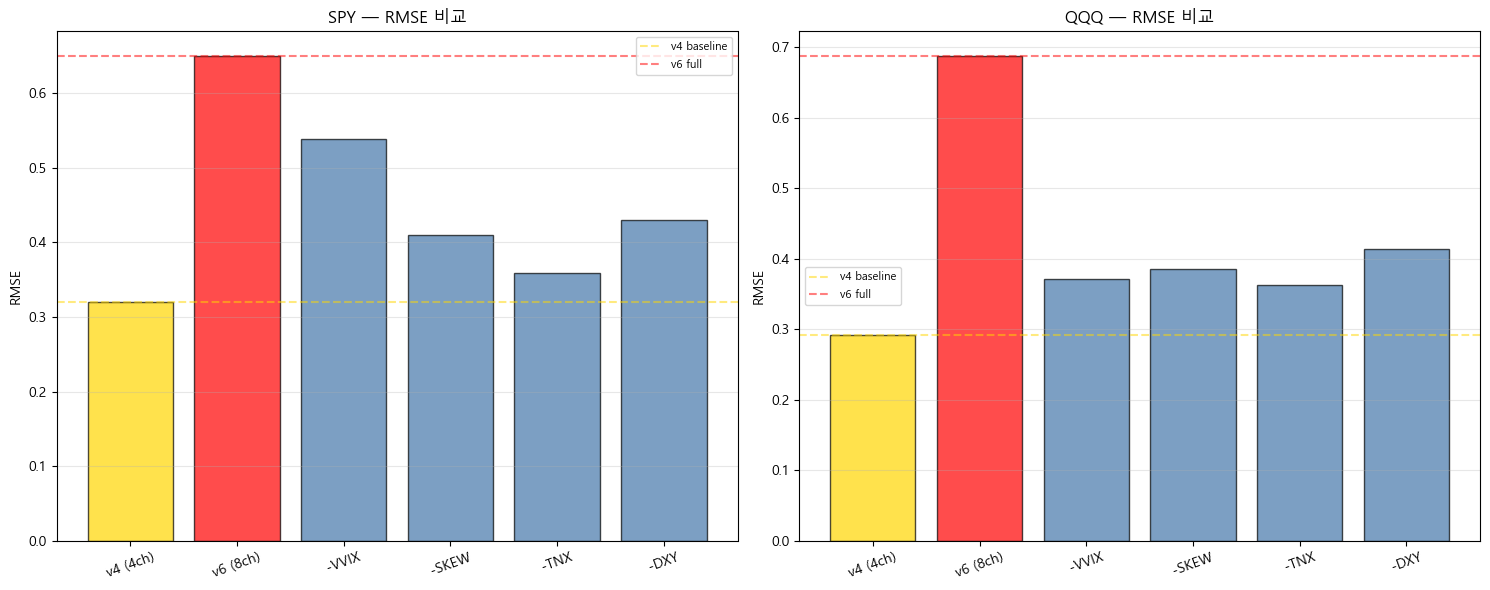

In [6]:
import matplotlib.pyplot as plt

# §6.A. RMSE 비교 bar (v4, v6 full, ablation 4)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for i, tk in enumerate(TICKERS):
    ax = axes[i]
    labels = ['v4 (4ch)', 'v6 (8ch)', '-VVIX', '-SKEW', '-TNX', '-DXY']
    rmses = [
        prior_results['v4'][tk]['rmse']['mean'],
        prior_results['v6'][tk]['rmse']['mean'],
    ]
    for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']:
        rmses.append(ablation_summary[tk][ab]['rmse']['mean'])
    colors = ['gold', 'red'] + ['#4477AA'] * 4
    ax.bar(labels, rmses, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(prior_results['v4'][tk]['rmse']['mean'], color='gold', ls='--', alpha=0.5,
                label=f'v4 baseline')
    ax.axhline(prior_results['v6'][tk]['rmse']['mean'], color='red', ls='--', alpha=0.5,
                label=f'v6 full')
    ax.set_title(f'{tk} — RMSE 비교')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


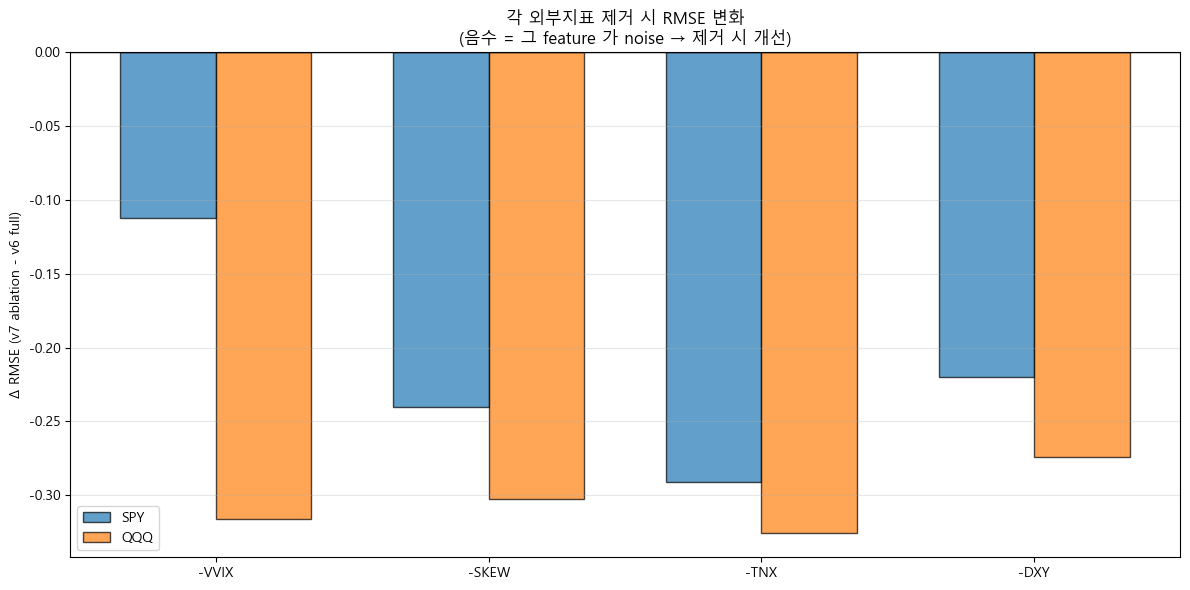

In [7]:
# §6.B. Ablation 효과 (Δ from v6 full): 각 외부지표 제거 시 RMSE 변화
fig, ax = plt.subplots(figsize=(12, 6))
abs_names = ['-VVIX', '-SKEW', '-TNX', '-DXY']
x = np.arange(len(abs_names))
width = 0.35

for i, tk in enumerate(TICKERS):
    deltas = []
    for ab in abs_names:
        v6_r = prior_results['v6'][tk]['rmse']['mean']
        ab_r = ablation_summary[tk][ab]['rmse']['mean']
        deltas.append(ab_r - v6_r)
    offset = (i - 0.5) * width
    colors_d = ['green' if d < 0 else 'red' for d in deltas]
    ax.bar(x + offset, deltas, width, label=tk, alpha=0.7,
            edgecolor='black')

ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(abs_names)
ax.set_ylabel('Δ RMSE (v7 ablation - v6 full)')
ax.set_title('각 외부지표 제거 시 RMSE 변화\n(음수 = 그 feature 가 noise → 제거 시 개선)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


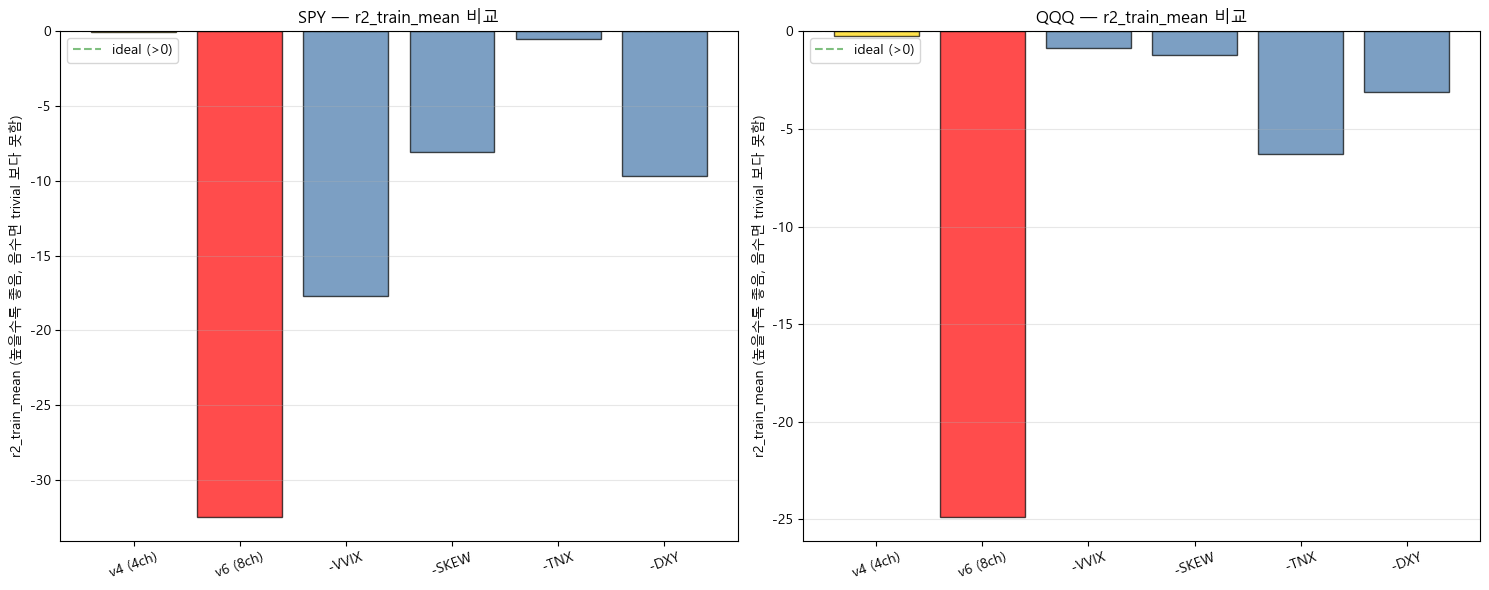

In [8]:
# §6.C. r2_train_mean 비교 (학습 안정성)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for i, tk in enumerate(TICKERS):
    ax = axes[i]
    labels = ['v4 (4ch)', 'v6 (8ch)', '-VVIX', '-SKEW', '-TNX', '-DXY']
    r2s = [
        prior_results['v4'][tk]['r2_train_mean']['mean'],
        prior_results['v6'][tk]['r2_train_mean']['mean'],
    ]
    for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']:
        r2s.append(ablation_summary[tk][ab]['r2_train_mean']['mean'])
    colors = ['gold', 'red'] + ['#4477AA'] * 4
    ax.bar(labels, r2s, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(0, color='green', ls='--', alpha=0.5, label='ideal (>0)')
    ax.set_title(f'{tk} — r2_train_mean 비교')
    ax.set_ylabel('r2_train_mean (높을수록 좋음, 음수면 trivial 보다 못함)')
    ax.tick_params(axis='x', rotation=20)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## §7. 결론 + 보고서 자동 생성


In [9]:
# 저장 폴더
OUT_DIR = RESULTS_DIR / 'lstm_v7_ablation'
OUT_DIR.mkdir(parents=True, exist_ok=True)


# 종목별 ablation metrics.json 저장
for tk in TICKERS:
    for ab in ABLATIONS:
        out = {
            'ticker': tk,
            'ablation': ab,
            'input_channels': ['rv_d'] + ABLATIONS[ab],
            'input_size': INPUT_SIZE,
            'summary': ablation_summary[tk][ab],
            'fold_predictions': ablation_results[(tk, ab)],
        }
        out_path = OUT_DIR / f'{tk}_{ab.replace("-", "minus_")}_metrics.json'
        with open(out_path, 'w', encoding='utf-8') as f:
            json.dump(out, f, ensure_ascii=False, indent=2)
print(f'저장: {len(TICKERS)} × {len(ABLATIONS)} = {len(TICKERS)*len(ABLATIONS)} JSON')


# 보고서 생성
report_path = RESULTS_DIR / 'v7_ablation_report.md'
lines = []
lines.append('# Phase 1.5 v7 — 외부지표 Ablation Study 보고서')
lines.append('')
lines.append('> v6 (8ch) 가 모든 종목에서 악화 → 어느 외부지표가 noise 인지 진단')
lines.append('')

lines.append('## 1. 전체 비교 표 (RMSE)')
lines.append('')
lines.append('| ticker | v4 (4ch) | v6 (8ch) | -VVIX | -SKEW | -TNX | -DXY |')
lines.append('|---|---|---|---|---|---|---|')
for tk in TICKERS:
    v4_r = prior_results['v4'][tk]['rmse']['mean']
    v6_r = prior_results['v6'][tk]['rmse']['mean']
    row = f'| {tk} | {v4_r:.4f} | {v6_r:.4f}'
    for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']:
        ab_r = ablation_summary[tk][ab]['rmse']['mean']
        row += f' | {ab_r:.4f}'
    row += ' |'
    lines.append(row)
lines.append('')

lines.append('## 2. Ablation 효과 — 각 외부지표 제거 시 v6 대비 Δ RMSE')
lines.append('')
lines.append('> Δ < 0 (음수): 그 feature 가 noise → 제거 시 개선')
lines.append('> Δ > 0 (양수): 그 feature 가 도움 → 제거 시 악화')
lines.append('')
lines.append('| ticker | -VVIX | -SKEW | -TNX | -DXY |')
lines.append('|---|---|---|---|---|')
all_deltas = {ab: [] for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']}
for tk in TICKERS:
    v6_r = prior_results['v6'][tk]['rmse']['mean']
    row = f'| {tk}'
    for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']:
        delta = ablation_summary[tk][ab]['rmse']['mean'] - v6_r
        all_deltas[ab].append(delta)
        marker = '✓' if delta < 0 else '✗'
        row += f' | {delta:+.4f} {marker}'
    row += ' |'
    lines.append(row)
# 평균
lines.append('| **avg** |' + ' | '.join(
    [f'{np.mean(all_deltas[ab]):+.4f}' for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']]
) + ' |')
lines.append('')

lines.append('## 3. 외부지표 importance 순위 (제거 시 개선 폭 큰 순 = 가장 noise)')
lines.append('')
ranking = sorted(
    [(ab, np.mean(all_deltas[ab])) for ab in ['-VVIX', '-SKEW', '-TNX', '-DXY']],
    key=lambda x: x[1]   # 가장 큰 음수가 1위 (노이즈 1위)
)
for i, (ab, d) in enumerate(ranking):
    indicator = ab.replace('-', '')
    if d < 0:
        verdict = f'🔴 가장 noise (제거 시 개선 평균 {d:+.4f})'
    elif d < 0.01:
        verdict = f'⚠️ 영향 미미 ({d:+.4f})'
    else:
        verdict = f'✓ 도움 (제거 시 악화 {d:+.4f})'
    lines.append(f'{i+1}. **{indicator}**: {verdict}')
lines.append('')

lines.append('## 4. 결론 + 다음 단계 권고')
lines.append('')

# 가장 큰 noise 식별
worst_indicator = ranking[0][0].replace('-', '')
worst_delta = ranking[0][1]

if worst_delta < -0.05:
    lines.append(f'**가장 큰 noise: {worst_indicator}** (제거 시 평균 {worst_delta:.4f} 개선)')
    lines.append('')
    lines.append(f'권고: **{worst_indicator} 제외하고 7ch 학습 → v4 best 와 비교**')
elif worst_delta < 0:
    lines.append(f'**모든 외부지표 noise 가능성** — 가장 큰 영향: {worst_indicator}')
    lines.append('')
    lines.append('권고: **외부지표 추가 효과 없음 → v4 best (4ch) 유지**')
else:
    lines.append('**모든 외부지표 약간이라도 도움** — v6 의 악화는 hidden=32 부족 가능성 ↑')
    lines.append('')
    lines.append('권고: **Optuna hyperparameter 재탐색 (hidden=64/128 시도)**')
lines.append('')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'저장: {report_path}')


print()
print('=' * 80)
print('Phase 1.5 v7 — Ablation Study 완료')
print('=' * 80)
print(f'\n외부지표 importance 순위 (avg Δ RMSE):')
for i, (ab, d) in enumerate(ranking):
    print(f'  {i+1}. {ab.replace("-", ""):<6} avg Δ = {d:>+.4f}')
print()
print(f'산출물: {report_path.relative_to(BASE_DIR)}')


저장: 2 × 4 = 8 JSON
저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\v7_ablation_report.md

Phase 1.5 v7 — Ablation Study 완료

외부지표 importance 순위 (avg Δ RMSE):
  1. TNX    avg Δ = -0.3083
  2. SKEW   avg Δ = -0.2714
  3. DXY    avg Δ = -0.2468
  4. VVIX   avg Δ = -0.2141

산출물: results\v7_ablation_report.md
